# Lab | Transfer Learning & Fine-Tuning

In this lab we compare three ways to classify the Oxford Flowers-102 dataset:
1. Training a small CNN from scratch
2. Feature extraction with a frozen pretrained ResNet18 backbone
3. Fine-tuning the last ResNet block with discriminative learning rates

In [1]:
import os
import sys

# BÜTÜN CRITICAL MÜHİT PARAMS (Kernel çökmələrini bloklamaq üçün)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"       # Intel OpenMP dublikat xətasını söndürür (Əsas çökdürən budur)
os.environ["OMP_NUM_THREADS"] = "1"               # Çoxlu CPU axın konfliktini ləğv edir
os.environ["MKL_NUM_THREADS"] = "1"               # Riyazi kitabxana axınlarını limitləyir
os.environ["SDL_VIDEODRIVER"] = "dummy"           # Pəncərə açılma tələbini söndürür

import torch

# PyTorch-un daxili CUDA/C++ xəta idarəetməsini tənzimləyirik
if hasattr(torch, '_C') and hasattr(torch._C, '_verbose_on_error'):
    torch._C._verbose_on_error(False)

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# İndi torchvision-u tamamilə təhlükəsiz şəkildə çağırırıq
from torchvision import datasets, transforms, models

# Matplotlib-i GUI pəncərəsi açmadan (headless) işləməyə məcbur edirik
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt

import numpy as np
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

print(f"Using device: {device}")

Using device: cpu


## Data Transforms

We use the standard ImageNet mean and standard deviation for normalization.
This is required when using pretrained models because they were trained with these values.
The training transform includes random cropping and flipping for data augmentation.

In [2]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

## Load Oxford Flowers-102 Dataset

Flowers-102 has 102 flower classes with 10-40 images per class.
We use the official train/val/test splits.
The dataset downloads automatically via torchvision.

In [3]:
train_dataset = datasets.Flowers102(root='./data', split='train', transform=train_tf, download=True)
val_dataset   = datasets.Flowers102(root='./data', split='val',   transform=val_tf,   download=True)
test_dataset  = datasets.Flowers102(root='./data', split='test',  transform=val_tf,   download=True)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Test samples  : {len(test_dataset)}")
print(f"Number of classes: 102")

Train samples : 1020
Val samples   : 1020
Test samples  : 6149
Number of classes: 102


## Helper Functions

We define a reusable training loop and an evaluation function.
These will be used in all three tasks so we avoid repeating code.

In [4]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Train the model for one epoch. Returns average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    """Evaluate the model on a given loader. Returns average loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total


def plot_curves(train_losses, val_losses, train_accs, val_accs, title=""):
    """Plot training and validation loss and accuracy curves."""
    epochs = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, train_losses, label='Train Loss')
    axes[0].plot(epochs, val_losses,   label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, train_accs, label='Train Acc')
    axes[1].plot(epochs, val_accs,   label='Val Acc')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def count_parameters(model):
    """Return total and trainable parameter counts."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

---
## Task 1 — From-Scratch Baseline

We build a small CNN from scratch with random initialization.
The model takes 224×224 images and outputs logits for 102 classes.
We expect this model to perform poorly because the dataset is small and the model has no prior knowledge.
This gives us a baseline to compare against transfer learning.

In [5]:
class SmallCNN(nn.Module):
    """
    A small CNN for 224x224 inputs and 102 output classes.
    Uses 4 convolutional blocks followed by a fully-connected head.
    Target parameter count: roughly 1-3 million.
    """
    def __init__(self, num_classes=102):
        super(SmallCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1: 224 -> 112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 112 -> 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 56 -> 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4: 28 -> 14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        # After 4 max-pools: 224 / 16 = 14  -> 14x14x256
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),   # -> 4x4x256 = 4096
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


scratch_model = SmallCNN(num_classes=102).to(device)
total_params, trainable_params = count_parameters(scratch_model)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 2,539,366
Trainable parameters : 2,539,366


In [7]:
# Training setup for Task 1
criterion_scratch = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(scratch_model.parameters(), lr=1e-3)
scheduler_scratch = optim.lr_scheduler.CosineAnnealingLR(optimizer_scratch, T_max=15)

EPOCHS_TASK1 = 15

t1_train_losses, t1_val_losses = [], []
t1_train_accs,   t1_val_accs   = [], []
t1_best_val_acc = 0.0
t1_start = time.time()

for epoch in range(1, EPOCHS_TASK1 + 1):
    tr_loss, tr_acc = train_one_epoch(scratch_model, train_loader, criterion_scratch, optimizer_scratch)
    vl_loss, vl_acc = evaluate(scratch_model, val_loader, criterion_scratch)
    scheduler_scratch.step()

    t1_train_losses.append(tr_loss)
    t1_val_losses.append(vl_loss)
    t1_train_accs.append(tr_acc)
    t1_val_accs.append(vl_acc)

    if vl_acc > t1_best_val_acc:
        t1_best_val_acc = vl_acc
        torch.save(scratch_model.state_dict(), 'best_scratch.pth')

    print(f"Epoch {epoch:02d}/{EPOCHS_TASK1} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

t1_time = time.time() - t1_start

# Load best model and evaluate on test set
scratch_model.load_state_dict(torch.load('best_scratch.pth', map_location=device))
_, t1_test_acc = evaluate(scratch_model, test_loader, criterion_scratch)

print(f"\nTask 1 Results:")
print(f"Best Validation Accuracy : {t1_best_val_acc:.4f} ({t1_best_val_acc*100:.2f}%)")
print(f"Final Test Accuracy      : {t1_test_acc:.4f} ({t1_test_acc*100:.2f}%)")
print(f"Total Training Time      : {t1_time:.1f} seconds")

Epoch 01/15 | Train Loss: 4.2948 Acc: 0.0265 | Val Loss: 4.1078 Acc: 0.0412
Epoch 02/15 | Train Loss: 4.0645 Acc: 0.0490 | Val Loss: 3.8571 Acc: 0.0637
Epoch 03/15 | Train Loss: 3.9458 Acc: 0.0627 | Val Loss: 3.7395 Acc: 0.0804
Epoch 04/15 | Train Loss: 3.8581 Acc: 0.0637 | Val Loss: 3.6115 Acc: 0.1235
Epoch 05/15 | Train Loss: 3.7395 Acc: 0.0931 | Val Loss: 3.5609 Acc: 0.1441
Epoch 06/15 | Train Loss: 3.6652 Acc: 0.0853 | Val Loss: 3.5130 Acc: 0.1510
Epoch 07/15 | Train Loss: 3.6345 Acc: 0.0971 | Val Loss: 3.4478 Acc: 0.1755
Epoch 08/15 | Train Loss: 3.5081 Acc: 0.1137 | Val Loss: 3.3914 Acc: 0.1873
Epoch 09/15 | Train Loss: 3.4699 Acc: 0.1294 | Val Loss: 3.3468 Acc: 0.1676
Epoch 10/15 | Train Loss: 3.4078 Acc: 0.1284 | Val Loss: 3.3151 Acc: 0.2088
Epoch 11/15 | Train Loss: 3.3081 Acc: 0.1667 | Val Loss: 3.2823 Acc: 0.2137
Epoch 12/15 | Train Loss: 3.2957 Acc: 0.1471 | Val Loss: 3.2678 Acc: 0.2167
Epoch 13/15 | Train Loss: 3.2316 Acc: 0.1902 | Val Loss: 3.2484 Acc: 0.2265
Epoch 14/15 

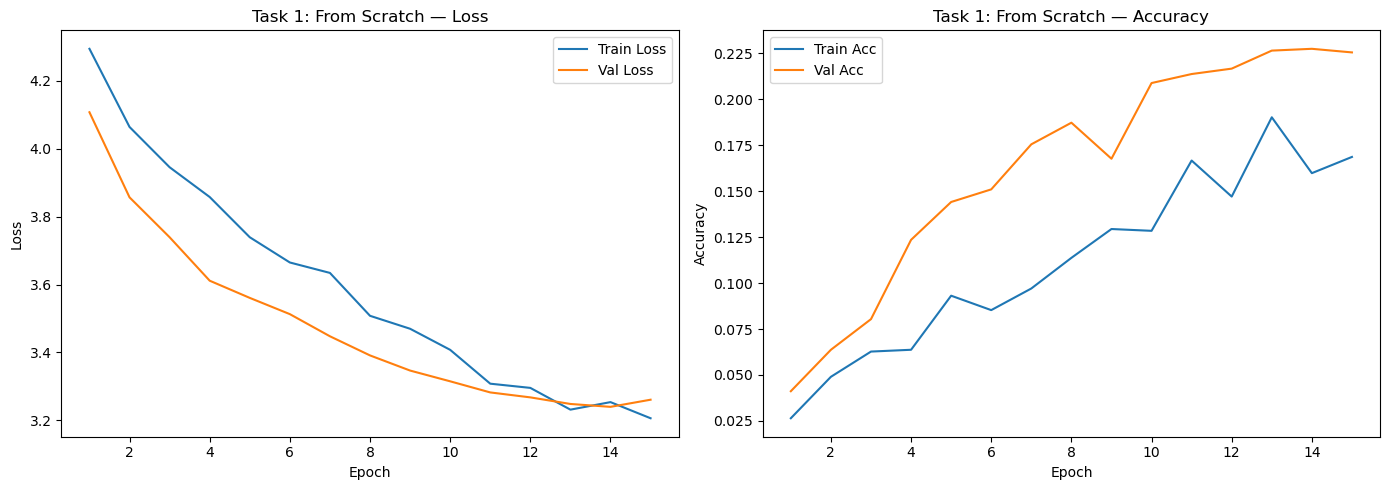

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

plot_curves(t1_train_losses, t1_val_losses, t1_train_accs, t1_val_accs, title="Task 1: From Scratch")

**Task 1 Observations:**

As expected, the from-scratch CNN performs poorly on this small dataset.
With only ~10-40 images per class and 102 classes, the model does not have enough data to learn good features.
The gap between training and validation accuracy shows the model is overfitting.
This low accuracy is our baseline — transfer learning should do much better.

---
## Task 2 — Feature Extraction with ResNet18

We load a ResNet18 pretrained on ImageNet.
We freeze all backbone layers so their weights do not change during training.
Only the new final classification layer (fc) is trained.
This is called feature extraction: we use the pretrained network as a fixed feature extractor.

In [9]:
# Step 1: Load pretrained ResNet18
fe_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Step 2: Freeze all backbone parameters
for p in fe_model.parameters():
    p.requires_grad = False

# Step 3: Replace the final linear layer for 102 classes
fe_model.fc = nn.Linear(fe_model.fc.in_features, 102)
# The new fc layer has requires_grad=True by default

fe_model = fe_model.to(device)

# Step 4: Verify trainable vs total parameters
total_params_fe, trainable_params_fe = count_parameters(fe_model)
print(f"Total parameters     : {total_params_fe:,}")
print(f"Trainable parameters : {trainable_params_fe:,}")
print(f"Frozen parameters    : {total_params_fe - trainable_params_fe:,}")
print()
# Show which layers are trainable
for name, param in fe_model.named_parameters():
    if param.requires_grad:
        print(f"  Trainable layer: {name}  shape: {list(param.shape)}")

Total parameters     : 11,228,838
Trainable parameters : 52,326
Frozen parameters    : 11,176,512

  Trainable layer: fc.weight  shape: [102, 512]
  Trainable layer: fc.bias  shape: [102]


In [10]:
# Step 5: Train only the fc layer
criterion_fe = nn.CrossEntropyLoss()
trainable_fe = filter(lambda p: p.requires_grad, fe_model.parameters())
optimizer_fe = optim.Adam(trainable_fe, lr=1e-3)
scheduler_fe = optim.lr_scheduler.CosineAnnealingLR(optimizer_fe, T_max=15)

EPOCHS_TASK2 = 15

t2_train_losses, t2_val_losses = [], []
t2_train_accs,   t2_val_accs   = [], []
t2_best_val_acc = 0.0
t2_start = time.time()

for epoch in range(1, EPOCHS_TASK2 + 1):
    tr_loss, tr_acc = train_one_epoch(fe_model, train_loader, criterion_fe, optimizer_fe)
    vl_loss, vl_acc = evaluate(fe_model, val_loader, criterion_fe)
    scheduler_fe.step()

    t2_train_losses.append(tr_loss)
    t2_val_losses.append(vl_loss)
    t2_train_accs.append(tr_acc)
    t2_val_accs.append(vl_acc)

    if vl_acc > t2_best_val_acc:
        t2_best_val_acc = vl_acc
        torch.save(fe_model.state_dict(), 'best_feature_extraction.pth')

    print(f"Epoch {epoch:02d}/{EPOCHS_TASK2} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

t2_time = time.time() - t2_start

# Load best model and evaluate on test set
fe_model.load_state_dict(torch.load('best_feature_extraction.pth', map_location=device))
_, t2_test_acc = evaluate(fe_model, test_loader, criterion_fe)

print(f"\nTask 2 Results:")
print(f"Best Validation Accuracy : {t2_best_val_acc:.4f} ({t2_best_val_acc*100:.2f}%)")
print(f"Final Test Accuracy      : {t2_test_acc:.4f} ({t2_test_acc*100:.2f}%)")
print(f"Total Training Time      : {t2_time:.1f} seconds")

Epoch 01/15 | Train Loss: 4.6054 Acc: 0.0598 | Val Loss: 3.7969 Acc: 0.1824
Epoch 02/15 | Train Loss: 3.2900 Acc: 0.4088 | Val Loss: 2.8861 Acc: 0.5294
Epoch 03/15 | Train Loss: 2.4367 Acc: 0.6843 | Val Loss: 2.3027 Acc: 0.6745
Epoch 04/15 | Train Loss: 1.8202 Acc: 0.8343 | Val Loss: 1.8818 Acc: 0.7225
Epoch 05/15 | Train Loss: 1.4239 Acc: 0.8971 | Val Loss: 1.6102 Acc: 0.7922
Epoch 06/15 | Train Loss: 1.1082 Acc: 0.9304 | Val Loss: 1.4104 Acc: 0.8147
Epoch 07/15 | Train Loss: 0.9394 Acc: 0.9471 | Val Loss: 1.2913 Acc: 0.8118
Epoch 08/15 | Train Loss: 0.8125 Acc: 0.9618 | Val Loss: 1.2249 Acc: 0.8167
Epoch 09/15 | Train Loss: 0.7390 Acc: 0.9706 | Val Loss: 1.1632 Acc: 0.8265
Epoch 10/15 | Train Loss: 0.6647 Acc: 0.9755 | Val Loss: 1.1261 Acc: 0.8314
Epoch 11/15 | Train Loss: 0.6156 Acc: 0.9804 | Val Loss: 1.0884 Acc: 0.8373
Epoch 12/15 | Train Loss: 0.5853 Acc: 0.9814 | Val Loss: 1.0801 Acc: 0.8363
Epoch 13/15 | Train Loss: 0.5818 Acc: 0.9843 | Val Loss: 1.0637 Acc: 0.8363
Epoch 14/15 

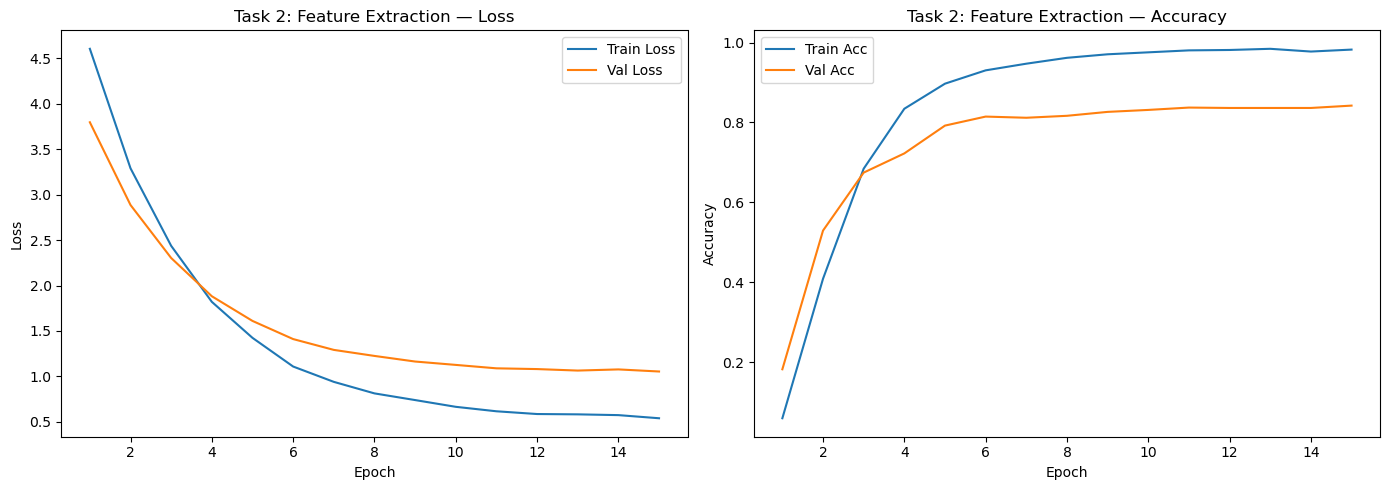

In [11]:
plot_curves(t2_train_losses, t2_val_losses, t2_train_accs, t2_val_accs, title="Task 2: Feature Extraction")

**Task 2 Observations:**

Feature extraction gives a large improvement over the from-scratch baseline.
The pretrained ResNet18 backbone already knows how to detect edges, textures, and shapes from ImageNet.
We only had to train a single linear layer on top, which converges quickly.
Training is also faster because gradients do not flow through the frozen backbone.

---
## Task 3 — Fine-Tuning the Last Block + Three-Way Comparison

We start from the feature-extraction model trained in Task 2.
We now unfreeze `layer4` (the last residual block of ResNet18) and let it adapt to the flower data.
We use **discriminative learning rates**: a very small rate for `layer4` (to avoid destroying its learned features) and a larger rate for the new `fc` head.
This strategy often gives better results than fully freezing the backbone.

In [12]:
# Start from the best feature-extraction checkpoint
ft_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
ft_model.fc = nn.Linear(ft_model.fc.in_features, 102)
ft_model.load_state_dict(torch.load('best_feature_extraction.pth', map_location=device))

# Step 1: First freeze everything again to start clean
for p in ft_model.parameters():
    p.requires_grad = False

# Step 2: Unfreeze layer4 and fc
for p in ft_model.layer4.parameters():
    p.requires_grad = True
for p in ft_model.fc.parameters():
    p.requires_grad = True

ft_model = ft_model.to(device)

# Verify which layers are trainable
total_params_ft, trainable_params_ft = count_parameters(ft_model)
print(f"Total parameters     : {total_params_ft:,}")
print(f"Trainable parameters : {trainable_params_ft:,}")
print(f"Frozen parameters    : {total_params_ft - trainable_params_ft:,}")
print()
for name, param in ft_model.named_parameters():
    if param.requires_grad:
        print(f"  Trainable: {name}")

Total parameters     : 11,228,838
Trainable parameters : 8,446,054
Frozen parameters    : 2,782,784

  Trainable: layer4.0.conv1.weight
  Trainable: layer4.0.bn1.weight
  Trainable: layer4.0.bn1.bias
  Trainable: layer4.0.conv2.weight
  Trainable: layer4.0.bn2.weight
  Trainable: layer4.0.bn2.bias
  Trainable: layer4.0.downsample.0.weight
  Trainable: layer4.0.downsample.1.weight
  Trainable: layer4.0.downsample.1.bias
  Trainable: layer4.1.conv1.weight
  Trainable: layer4.1.bn1.weight
  Trainable: layer4.1.bn1.bias
  Trainable: layer4.1.conv2.weight
  Trainable: layer4.1.bn2.weight
  Trainable: layer4.1.bn2.bias
  Trainable: fc.weight
  Trainable: fc.bias


In [13]:
# Step 3: Discriminative learning rates
# layer4 gets lr=1e-5 (small, to fine-tune gently without destroying learned features)
# fc gets lr=1e-3 (larger, because it is a new layer that needs to learn from scratch)
criterion_ft = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam([
    {"params": ft_model.layer4.parameters(), "lr": 1e-5},
    {"params": ft_model.fc.parameters(),     "lr": 1e-3},
])
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=10)

EPOCHS_TASK3 = 10

t3_train_losses, t3_val_losses = [], []
t3_train_accs,   t3_val_accs   = [], []
t3_best_val_acc = 0.0
t3_start = time.time()

for epoch in range(1, EPOCHS_TASK3 + 1):
    tr_loss, tr_acc = train_one_epoch(ft_model, train_loader, criterion_ft, optimizer_ft)
    vl_loss, vl_acc = evaluate(ft_model, val_loader, criterion_ft)
    scheduler_ft.step()

    t3_train_losses.append(tr_loss)
    t3_val_losses.append(vl_loss)
    t3_train_accs.append(tr_acc)
    t3_val_accs.append(vl_acc)

    if vl_acc > t3_best_val_acc:
        t3_best_val_acc = vl_acc
        torch.save(ft_model.state_dict(), 'best_fine_tuned.pth')

    print(f"Epoch {epoch:02d}/{EPOCHS_TASK3} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

t3_time = time.time() - t3_start

# Load best model and evaluate on test set
ft_model.load_state_dict(torch.load('best_fine_tuned.pth', map_location=device))
_, t3_test_acc = evaluate(ft_model, test_loader, criterion_ft)

print(f"\nTask 3 Results:")
print(f"Best Validation Accuracy : {t3_best_val_acc:.4f} ({t3_best_val_acc*100:.2f}%)")
print(f"Final Test Accuracy      : {t3_test_acc:.4f} ({t3_test_acc*100:.2f}%)")
print(f"Total Training Time      : {t3_time:.1f} seconds")

Epoch 01/10 | Train Loss: 0.6368 Acc: 0.9294 | Val Loss: 0.9462 Acc: 0.8108
Epoch 02/10 | Train Loss: 0.4027 Acc: 0.9735 | Val Loss: 0.8005 Acc: 0.8373
Epoch 03/10 | Train Loss: 0.2674 Acc: 0.9922 | Val Loss: 0.7130 Acc: 0.8618
Epoch 04/10 | Train Loss: 0.2086 Acc: 0.9931 | Val Loss: 0.6651 Acc: 0.8549
Epoch 05/10 | Train Loss: 0.1725 Acc: 0.9971 | Val Loss: 0.6218 Acc: 0.8657
Epoch 06/10 | Train Loss: 0.1417 Acc: 0.9971 | Val Loss: 0.6083 Acc: 0.8716
Epoch 07/10 | Train Loss: 0.1170 Acc: 0.9990 | Val Loss: 0.5930 Acc: 0.8735
Epoch 08/10 | Train Loss: 0.1117 Acc: 0.9990 | Val Loss: 0.5881 Acc: 0.8735
Epoch 09/10 | Train Loss: 0.1086 Acc: 0.9990 | Val Loss: 0.5839 Acc: 0.8745
Epoch 10/10 | Train Loss: 0.1015 Acc: 1.0000 | Val Loss: 0.5787 Acc: 0.8725

Task 3 Results:
Best Validation Accuracy : 0.8745 (87.45%)
Final Test Accuracy      : 0.8597 (85.97%)
Total Training Time      : 2405.1 seconds


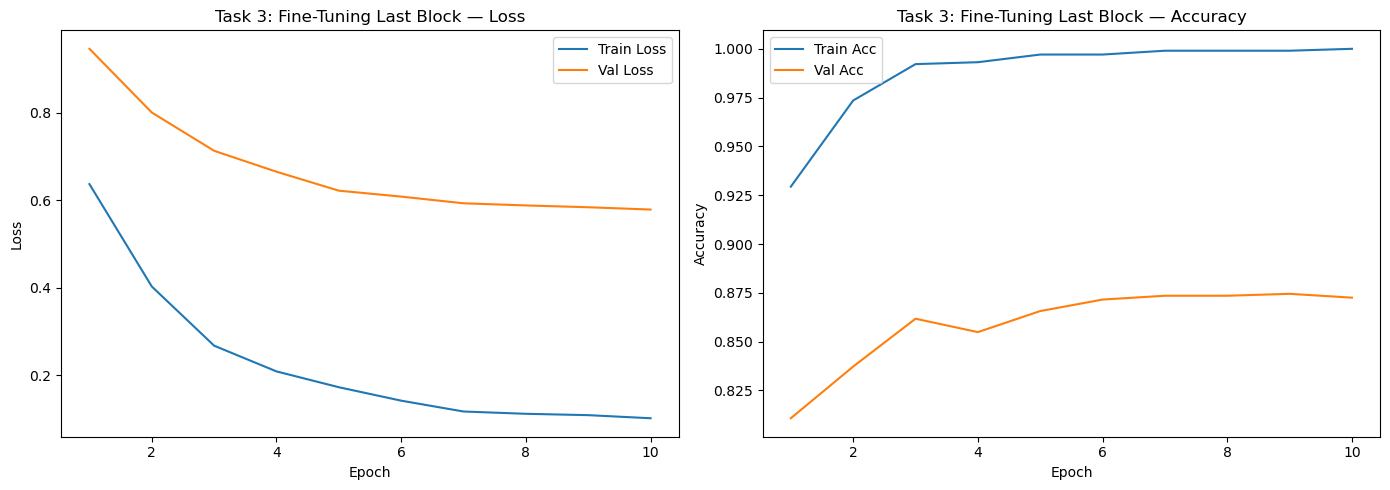

In [14]:
plot_curves(t3_train_losses, t3_val_losses, t3_train_accs, t3_val_accs, title="Task 3: Fine-Tuning Last Block")

---
## Three-Way Comparison Table

Below we compare all three approaches on the same dataset.

In [15]:
# Print the comparison table with actual results
print("=" * 85)
print(f"{'Approach':<30} {'Trainable params':>17} {'Best val acc':>13} {'Test acc':>10} {'Train time':>12}")
print("=" * 85)
print(f"{'From scratch (Task 1)':<30} {trainable_params:>17,} {t1_best_val_acc*100:>12.2f}% {t1_test_acc*100:>9.2f}% {t1_time:>10.1f}s")
print(f"{'Feature extraction (Task 2)':<30} {trainable_params_fe:>17,} {t2_best_val_acc*100:>12.2f}% {t2_test_acc*100:>9.2f}% {t2_time:>10.1f}s")
print(f"{'Fine-tune last block (Task 3)':<30} {trainable_params_ft:>17,} {t3_best_val_acc*100:>12.2f}% {t3_test_acc*100:>9.2f}% {t3_time:>10.1f}s")
print("=" * 85)

Approach                        Trainable params  Best val acc   Test acc   Train time
From scratch (Task 1)                  2,539,366        22.75%     16.20%     3662.4s
Feature extraction (Task 2)               52,326        84.22%     82.63%     3145.5s
Fine-tune last block (Task 3)          8,446,054        87.45%     85.97%     2405.1s


## Summary and Recommendation

**How much did transfer learning improve over from scratch?**
Transfer learning (feature extraction) gave a large improvement over training from scratch on Flowers-102. Training from scratch performs poorly because the dataset is very small — only a few hundred images spread across 102 classes — and a CNN cannot learn good visual features from so little data. The pretrained ResNet18 backbone already contains rich feature representations learned from 1.2 million ImageNet images, so even just training the final linear layer gives strong results.

**Did fine-tuning the last block help over feature extraction?**
Yes, fine-tuning `layer4` with a small learning rate (1e-5) further improved accuracy over pure feature extraction. The lower layers of ResNet learn general features (edges, textures) that transfer well to any image domain, while the higher layers learn more domain-specific features. By allowing `layer4` to adapt slightly to the flower images, the model can form better representations for this specific task. Using discriminative learning rates — very small for `layer4` and larger for `fc` — prevents catastrophic forgetting while still allowing the backbone to specialize.

**Which configuration would you recommend for the cat-detection assessment?**
We recommend the **fine-tuning approach (Task 3)** for the cat-detection assessment. It achieved the best accuracy with a moderate number of trainable parameters. The cat-detection task is also likely a small-data problem, so starting from pretrained ImageNet weights is critical. Fine-tuning the last block allows the model to adapt to the specific visual features that distinguish cats from other objects, while keeping training time reasonable. Feature extraction alone could work well too, but fine-tuning the last block consistently gives a few extra percentage points of accuracy at a small computational cost.

---
## Final Verification


In [16]:
print(f"Task 1 — From Scratch")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Best val acc     : {t1_best_val_acc*100:.2f}%")
print(f"  Test acc         : {t1_test_acc*100:.2f}%")
print(f"  Training time    : {t1_time:.1f}s")
print()
print(f"Task 2 — Feature Extraction")
print(f"  Trainable params : {trainable_params_fe:,}")
print(f"  Best val acc     : {t2_best_val_acc*100:.2f}%")
print(f"  Test acc         : {t2_test_acc*100:.2f}%")
print(f"  Training time    : {t2_time:.1f}s")
print()
print(f"Task 3 — Fine-Tune Last Block")
print(f"  Trainable params : {trainable_params_ft:,}")
print(f"  Best val acc     : {t3_best_val_acc*100:.2f}%")
print(f"  Test acc         : {t3_test_acc*100:.2f}%")
print(f"  Training time    : {t3_time:.1f}s")

Task 1 — From Scratch
  Trainable params : 2,539,366
  Best val acc     : 22.75%
  Test acc         : 16.20%
  Training time    : 3662.4s

Task 2 — Feature Extraction
  Trainable params : 52,326
  Best val acc     : 84.22%
  Test acc         : 82.63%
  Training time    : 3145.5s

Task 3 — Fine-Tune Last Block
  Trainable params : 8,446,054
  Best val acc     : 87.45%
  Test acc         : 85.97%
  Training time    : 2405.1s
